# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

C:\Users\lemrd\AppData\Local\Temp\ipykernel_27236\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

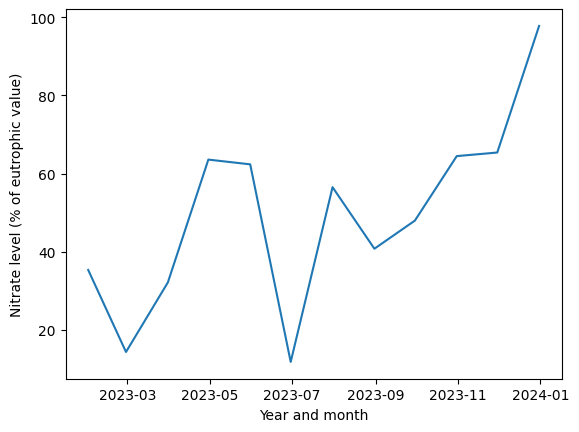

In [4]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\lemrd\AppData\Local\Temp\ipykernel_27236\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

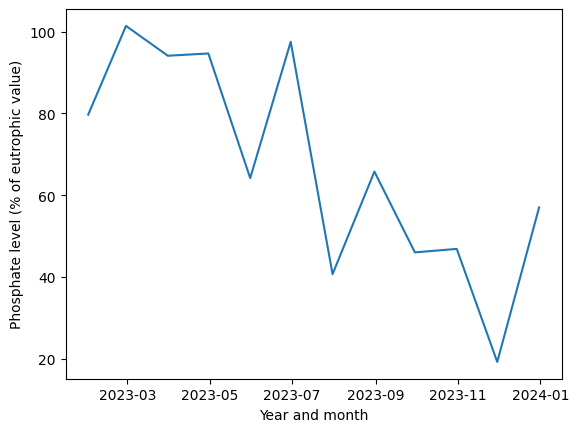

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

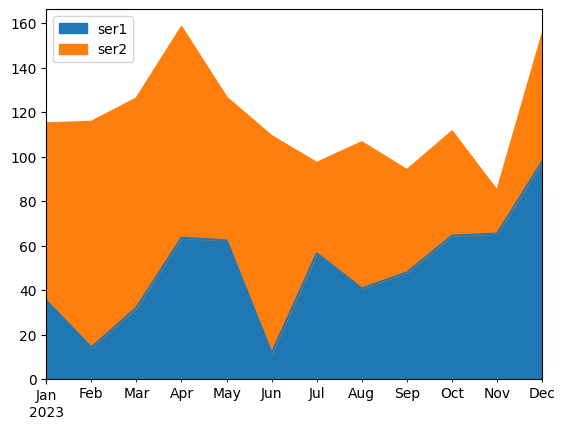

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Since the area plot stacks the two lines, it would be helpful for showing the combined value of Phosphate and Nitrate and makes it easy to see the ratio of the chemicals to each other. The sum total is fairly consistent across the area plot, so it seems like it might be particularly effect in showing how the ratio changes over time. 

If neither the ratio nor combined level are important, then I would recommend just the line plots. When each measurement is important on its own, you show not stack them and hide the values in a sum. If just the ratio is unimportant, then stick to the line plots because you could always add a seperate line for the sum total of the others. 

To improve the plots, the area plot really needs labels on y scale and series. The line plots could be condensed into one graph, since they have the same measurements on a very similar scale. Right now, neither plot is doing anything to focus attention. Based on the important information the formatting could be changed for emphasis.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [10]:
import matplotlib.pyplot as plt


In [ ]:
#Import first dataset, 2015 Flight Delay Data
#Columns 7,8 needed dtype specified directly as infer failed
#Copying over the same preparation steps from previous HWs

flights_2015 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2015_Delay_Data\flights.csv", dtype={"DESTINATION_AIRPORT":str, "ORIGIN_AIRPORT":str})

flights_2015.fillna({"AIR_SYSTEM_DELAY":0,"SECURITY_DELAY":0,"AIRLINE_DELAY":0,"LATE_AIRCRAFT_DELAY":0,"WEATHER_DELAY":0}, inplace=True)
flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [8]:
flights_2015.drop(["YEAR", "DAY", "FLIGHT_NUMBER", "SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "WHEELS_OFF", "WHEELS_ON", "SCHEDULED_ARRIVAL", "ARRIVAL_TIME", "DIVERTED", "CANCELLED"], axis=1).corr(numeric_only=True)

,MONTH,DAY_OF_WEEK,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,TAXI_IN,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
MONTH,1.000000,-0.007847,-0.021994,-0.013117,0.010784,0.001871,0.003379,0.011437,0.002095,-0.036793,-0.016943,0.002099,-0.008968,-0.015900,-0.008840
DAY_OF_WEEK,-0.007847,1.000000,-0.011510,-0.020639,0.014954,0.011510,0.014284,0.016516,0.001111,-0.017027,-0.013891,0.000296,0.000600,-0.012028,-0.004359
DEPARTURE_DELAY,-0.021994,-0.011510,1.000000,0.058515,0.027799,0.030805,0.023495,0.024106,0.012784,0.944672,0.302417,0.028067,0.653523,0.647186,0.263490
TAXI_OUT,-0.013117,-0.020639,0.058515,1.000000,0.112302,0.205195,0.087608,0.072333,0.003221,0.227319,0.337070,0.003718,0.036223,0.027782,0.076862
SCHEDULED_TIME,0.010784,0.014954,0.027799,0.112302,1.000000,0.985260,0.990749,0.984336,0.099036,-0.030029,0.015144,0.003286,0.016010,-0.013559,0.000339
ELAPSED_TIME,0.001871,0.011510,0.030805,0.205195,0.985260,1.000000,0.990033,0.973696,0.156179,0.029120,0.087992,0.004111,0.020725,-0.008943,0.011169
AIR_TIME,0.003379,0.014284,0.023495,0.087608,0.990749,0.990033,1.000000,0.985643,0.082292,-0.007108,0.033249,0.003764,0.016320,-0.013927,0.000923
DISTANCE,0.011437,0.016516,0.024106,0.072333,0.984336,0.973696,0.985643,1.000000,0.075232,-0.025444,0.009067,0.003461,0.015620,-0.013557,-0.002671
TAXI_IN,0.002095,0.001111,0.012784,0.003221,0.099036,0.156179,0.082292,0.075232,1.000000,0.116628,0.198994,-0.000011,0.006122,0.016348,0.013598
ARRIVAL_DELAY,-0.036793,-0.017027,0.944672,0.227319,-0.030029,0.029120,-0.007108,-0.025444,0.116628,1.000000,0.424414,0.028074,0.627489,0.622980,0.270098


This is an entire year's worth of flight data, most of the columns were not going to be correlated. Distance is positively correlated with the expected and measured duration of the flights. Depature delays are highly correlated with arrival delays. Really, this correlatin matrix just demonstrates why predicting delays is an interesting question. It does not have any easy answers.

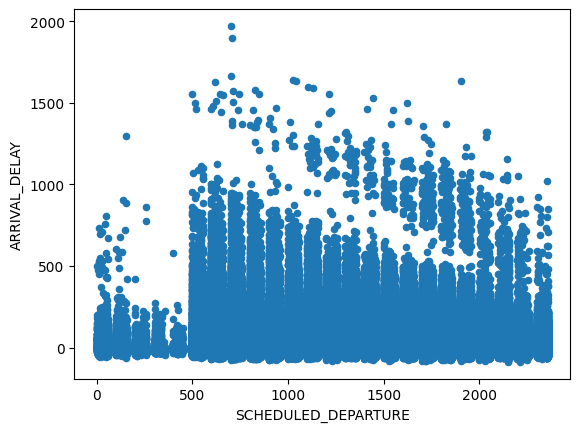

In [10]:
flights_2015.plot.scatter("SCHEDULED_DEPARTURE", "ARRIVAL_DELAY");

In [11]:
flights_2015["ELAPSED_TIME"].mean()

np.float64(137.00618917579393)

Well that is an unexpected shape. I wanted to see if there were any patterns to when a flight took off and, in total, how delayed it landed. 

The slice missing seems to relate to when flights are likely to occur in a given day. A 5 AM flight delayed more than 18 hours (11 PM that night) is simply pushed back to the 4/5 AM slot the next day (which would land at about 1560 minutes given average flight time). That is why there is no data between 1200 and 1440 minutes on the arrival delay. That same approximate "dead space" of no delayed flights happened from midnight to 5 AM stays visible through most of the data.

In [22]:
flights_2015.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].describe()

,count,mean,std,min,25%,50%,75%,max
DAY_OF_WEEK,,,,,,,,
1,841794.0,6.002063,42.580684,-81.0,-13.0,-5.0,9.0,1636.0
2,827399.0,4.246041,39.056802,-80.0,-13.0,-5.0,7.0,1598.0
3,843242.0,3.845468,37.415150,-82.0,-13.0,-5.0,7.0,1576.0
4,857886.0,5.668334,39.429474,-87.0,-12.0,-4.0,9.0,1636.0
5,851387.0,4.764079,37.894314,-79.0,-13.0,-4.0,9.0,1971.0
6,689745.0,1.852892,38.185774,-87.0,-14.0,-6.0,5.0,1898.0
7,802555.0,3.958293,39.824708,-80.0,-14.0,-5.0,7.0,1665.0


In [3]:
#Import 2nd Dataset, 2019 Flight Delay Info

delays_2019 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2019_Delay_Data\full_data_flightdelay.csv")

delays_2019.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


In [4]:
delays_2019.corr(numeric_only=True)

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,...,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,LATITUDE,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND
MONTH,1.000000,0.006727,-0.019049,-0.002561,0.016712,0.022951,0.003155,0.036913,0.038884,0.018836,...,0.000873,-0.004257,-0.017344,0.012913,-0.004548,-0.005133,-0.053596,-0.088596,0.173454,-0.119272
DAY_OF_WEEK,0.006727,1.000000,-0.000199,0.013550,-0.029812,-0.027214,0.009300,-0.001725,-0.006282,-0.002327,...,0.000519,0.001153,-0.005785,-0.011503,-0.006120,0.018205,-0.005883,-0.009878,0.007513,0.001785
DEP_DEL15,-0.019049,-0.000199,1.000000,0.016289,0.117528,0.009028,0.011845,0.026740,0.003528,0.013711,...,-0.002114,-0.016736,0.006220,0.000490,0.027097,0.080277,0.050156,0.026129,-0.008936,0.050947
DISTANCE_GROUP,-0.002561,0.013550,0.016289,1.000000,-0.237415,-0.035572,0.447485,-0.013700,-0.003279,-0.035004,...,0.167134,0.266503,-0.138314,-0.011182,-0.159929,-0.012478,-0.000485,-0.007388,0.003697,0.023392
SEGMENT_NUMBER,0.016712,-0.029812,0.117528,-0.237415,1.000000,0.014240,-0.202832,0.042633,0.027261,0.056441,...,-0.098353,-0.183047,0.076003,-0.034347,-0.070426,-0.016279,-0.014711,-0.006888,0.029219,-0.024107
CONCURRENT_FLIGHTS,0.022951,-0.027214,0.009028,-0.035572,0.014240,1.000000,-0.054131,0.849023,-0.043085,0.582488,...,0.122495,0.103521,0.036077,0.018230,0.118662,-0.015074,-0.017250,-0.027321,0.026031,0.059272
NUMBER_OF_SEATS,0.003155,0.009300,0.011845,0.447485,-0.202832,-0.054131,1.000000,0.003574,0.308104,0.161800,...,0.204501,0.343823,-0.102969,-0.136366,-0.161854,-0.014044,-0.008511,-0.015707,0.061254,-0.018506
AIRPORT_FLIGHTS_MONTH,0.036913,-0.001725,0.026740,-0.013700,0.042633,0.849023,0.003574,1.000000,-0.019744,0.648140,...,0.148205,0.107796,0.027185,0.019066,0.091296,-0.010380,-0.009837,-0.032679,0.038819,0.071717
AIRLINE_FLIGHTS_MONTH,0.038884,-0.006282,0.003528,-0.003279,0.027261,-0.043085,0.308104,-0.019744,1.000000,0.230914,...,0.002775,-0.067201,0.170682,-0.027490,-0.080197,-0.008108,-0.012901,-0.024357,0.076706,-0.047277
AIRLINE_AIRPORT_FLIGHTS_MONTH,0.018836,-0.002327,0.013711,-0.035004,0.056441,0.582488,0.161800,0.648140,0.230914,1.000000,...,0.142726,0.131619,0.115853,-0.066772,0.071855,-0.000840,-0.019745,-0.032805,0.067799,0.008097


<Axes: xlabel='AIRPORT_FLIGHTS_MONTH', ylabel='AVG_MONTHLY_PASS_AIRPORT'>

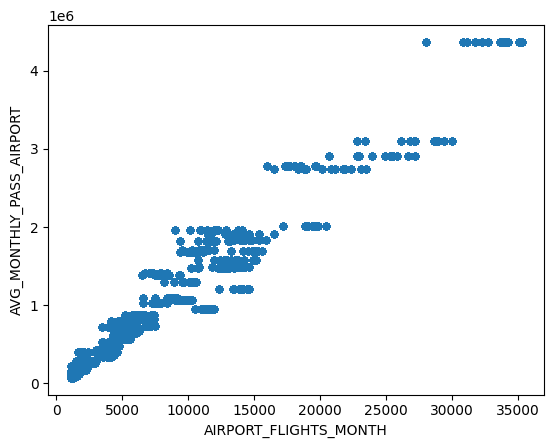

In [6]:
delays_2019.plot.scatter("AIRPORT_FLIGHTS_MONTH", "AVG_MONTHLY_PASS_AIRPORT")

In [7]:
delays_2019.groupby("DAY_OF_WEEK")["DEP_DEL15"].describe()

,count,mean,std,min,25%,50%,75%,max
DAY_OF_WEEK,,,,,,,,
1,967364.0,0.197863,0.398389,0.0,0.0,0.0,0.0,1.0
2,946470.0,0.174424,0.379474,0.0,0.0,0.0,0.0,1.0
3,938328.0,0.180367,0.384493,0.0,0.0,0.0,0.0,1.0
4,955682.0,0.205893,0.404353,0.0,0.0,0.0,0.0,1.0
5,969141.0,0.199942,0.399957,0.0,0.0,0.0,0.0,1.0
6,789918.0,0.168964,0.374721,0.0,0.0,0.0,0.0,1.0
7,922159.0,0.192618,0.394355,0.0,0.0,0.0,0.0,1.0


In [8]:
delays_2019.groupby("SEGMENT_NUMBER")["DEP_DEL15"].describe()

,count,mean,std,min,25%,50%,75%,max
SEGMENT_NUMBER,,,,,,,,
1,1449009.0,0.122103,0.327405,0.0,0.0,0.0,0.0,1.0
2,1505083.0,0.159704,0.366332,0.0,0.0,0.0,0.0,1.0
3,1182583.0,0.199712,0.399784,0.0,0.0,0.0,0.0,1.0
4,1062789.0,0.226166,0.418348,0.0,0.0,0.0,0.0,1.0
5,605609.0,0.258702,0.437922,0.0,0.0,0.0,1.0,1.0
6,446805.0,0.253296,0.434900,0.0,0.0,0.0,1.0,1.0
7,136254.0,0.294744,0.455929,0.0,0.0,0.0,1.0,1.0
8,79636.0,0.250038,0.433037,0.0,0.0,0.0,1.0,1.0
9,10151.0,0.251305,0.433785,0.0,0.0,0.0,1.0,1.0


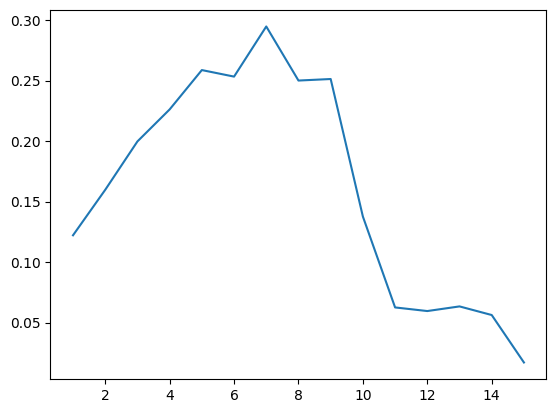

In [16]:
plt.plot(np.linspace(1,15,15),delays_2019.groupby("SEGMENT_NUMBER")["DEP_DEL15"].mean())

Segment number is the number of the flight for that plane that day. A segment number of 3 means that plane is on its 3rd flight that day. "DEP_DEL15" is a binary checking if there was more than a 15 minute departure delay. Segment number has the strongest correlation of any of the variables with notable departure delays. The sample size of segment number drops off towards the higher values, but it is still interesting that the percentage of delays drops off considerably for flights 11 and onward.

<Axes: xlabel='PRCP', ylabel='SNOW'>

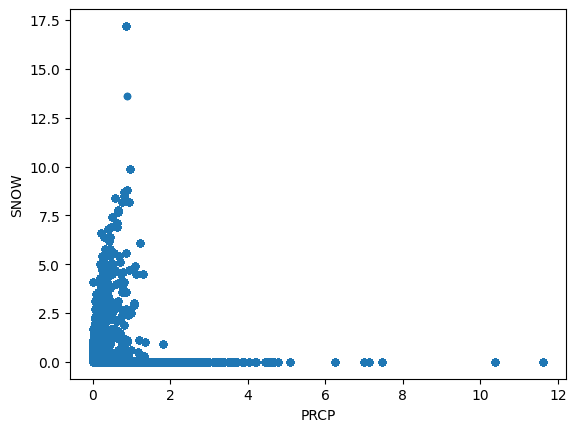

In [17]:
delays_2019.plot.scatter("PRCP", "SNOW")

Interesting that snow must not be included in precipitation measurements. This is the precipitation (in inches) versus the snowfall (in inches) the day of the flight. I had been expected higher correlation between these two variables, but now I see their definitions were not what I expected.

<Axes: xlabel='SNWD', ylabel='SNOW'>

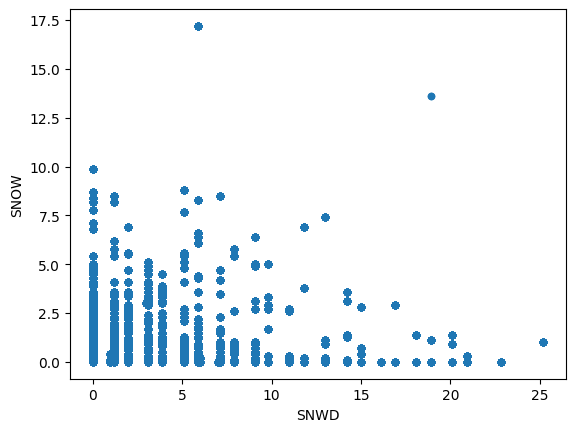

In [18]:
delays_2019.plot.scatter("SNWD", "SNOW")

In [21]:
delays_2019["SNWD"].unique()

array([ 0. ,  3.9,  5.9,  3.1,  1.2,  2. ,  5.1, 11. ,  7.9,  7.1,  9.8,
        9.1, 25.2, 18.9, 13. , 11.8, 15. , 14.2, 16.1, 20.9, 16.9, 20.1,
       22.8, 18.1,  6. ,  7. ,  1. ,  3. ])

I had certainly thought there would be more than 28 measurements for amount of snow on the ground.

In [60]:
#Import 3rd Dataset
#Prep work from HW2

delay_causes = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\Flight_Delay_and_Causes_Data\Flight_delay.csv")

delay_causes.drop_duplicates(keep="first", inplace=True)
                           
delay_causes.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [61]:
delay_causes.corr(numeric_only=True)

,DayOfWeek,DepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
DayOfWeek,1.000000,0.018649,0.008181,0.013005,-0.012214,0.004801,0.009373,0.007838,-0.002553,0.003026,0.011913,0.011218,-0.016737,NaN,NaN,0.016825,0.001648,-0.026705,0.005742,-0.000288
DepTime,0.018649,1.000000,0.363241,0.702808,-0.029191,-0.072031,-0.055899,-0.066995,0.106641,0.132380,-0.064509,-0.042003,-0.026434,NaN,NaN,-0.042486,0.000472,0.004865,-0.018189,0.188047
ArrTime,0.008181,0.363241,1.000000,0.500788,0.006503,-0.039457,-0.041243,-0.041937,-0.071197,-0.072949,-0.055781,0.030342,-0.009850,NaN,NaN,-0.075551,-0.025724,0.030974,-0.010336,-0.037782
CRSArrTime,0.013005,0.702808,0.500788,1.000000,-0.061337,0.010091,0.022882,0.011535,0.028813,0.045206,0.012402,-0.009453,-0.000573,NaN,NaN,-0.089387,-0.019192,-0.007640,-0.016704,0.143358
FlightNum,-0.012214,-0.029191,0.006503,-0.061337,1.000000,-0.334004,-0.353530,-0.354270,0.025788,0.016372,-0.369567,0.006771,0.004032,NaN,NaN,0.036286,0.062789,0.038481,-0.000900,-0.059068
ActualElapsedTime,0.004801,-0.072031,-0.039457,0.010091,-0.334004,1.000000,0.969723,0.975322,0.091506,0.009281,0.950683,0.175882,0.307644,NaN,NaN,0.029732,-0.004328,0.171725,0.000934,-0.031510
CRSElapsedTime,0.009373,-0.055899,-0.041243,0.022882,-0.353530,0.969723,1.000000,0.986646,0.040953,0.036579,0.983551,0.110105,0.133169,NaN,NaN,0.045671,-0.025444,0.047489,0.001622,-0.011533
AirTime,0.007838,-0.066995,-0.041937,0.011535,-0.354270,0.975322,0.986646,1.000000,0.039962,0.011101,0.977436,0.097938,0.103517,NaN,NaN,0.037612,-0.024446,0.069139,0.002494,-0.022409
ArrDelay,-0.002553,0.106641,-0.071197,0.028813,0.025788,0.091506,0.040953,0.039962,1.000000,0.948856,0.027743,0.106703,0.220981,NaN,NaN,0.478471,0.266126,0.395435,-0.002701,0.505515
DepDelay,0.003026,0.132380,-0.072949,0.045206,0.016372,0.009281,0.036579,0.011101,0.948856,1.000000,0.027307,0.016591,-0.011958,NaN,NaN,0.505906,0.244019,0.235892,-0.001912,0.541351


In [62]:
delay_causes["Cancelled"].unique()

array([0])

In [63]:
delay_causes["Diverted"].unique()

array([0])

In [64]:
delay_causes["CancellationCode"].unique()

array(['N'], dtype=object)

I had not realized that this dataset had removed any cancelled or diverted flights. That makes these three columns useless and they should be dropped.

In [65]:
delay_causes.drop(["Cancelled","Diverted","CancellationCode"],axis=1, inplace=True)

In [66]:
delay_causes.drop(["FlightNum"], axis=1).corr(numeric_only=True)

,DayOfWeek,DepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
DayOfWeek,1.000000,0.018649,0.008181,0.013005,0.004801,0.009373,0.007838,-0.002553,0.003026,0.011913,0.011218,-0.016737,0.016825,0.001648,-0.026705,0.005742,-0.000288
DepTime,0.018649,1.000000,0.363241,0.702808,-0.072031,-0.055899,-0.066995,0.106641,0.132380,-0.064509,-0.042003,-0.026434,-0.042486,0.000472,0.004865,-0.018189,0.188047
ArrTime,0.008181,0.363241,1.000000,0.500788,-0.039457,-0.041243,-0.041937,-0.071197,-0.072949,-0.055781,0.030342,-0.009850,-0.075551,-0.025724,0.030974,-0.010336,-0.037782
CRSArrTime,0.013005,0.702808,0.500788,1.000000,0.010091,0.022882,0.011535,0.028813,0.045206,0.012402,-0.009453,-0.000573,-0.089387,-0.019192,-0.007640,-0.016704,0.143358
ActualElapsedTime,0.004801,-0.072031,-0.039457,0.010091,1.000000,0.969723,0.975322,0.091506,0.009281,0.950683,0.175882,0.307644,0.029732,-0.004328,0.171725,0.000934,-0.031510
CRSElapsedTime,0.009373,-0.055899,-0.041243,0.022882,0.969723,1.000000,0.986646,0.040953,0.036579,0.983551,0.110105,0.133169,0.045671,-0.025444,0.047489,0.001622,-0.011533
AirTime,0.007838,-0.066995,-0.041937,0.011535,0.975322,0.986646,1.000000,0.039962,0.011101,0.977436,0.097938,0.103517,0.037612,-0.024446,0.069139,0.002494,-0.022409
ArrDelay,-0.002553,0.106641,-0.071197,0.028813,0.091506,0.040953,0.039962,1.000000,0.948856,0.027743,0.106703,0.220981,0.478471,0.266126,0.395435,-0.002701,0.505515
DepDelay,0.003026,0.132380,-0.072949,0.045206,0.009281,0.036579,0.011101,0.948856,1.000000,0.027307,0.016591,-0.011958,0.505906,0.244019,0.235892,-0.001912,0.541351
Distance,0.011913,-0.064509,-0.055781,0.012402,0.950683,0.983551,0.977436,0.027743,0.027307,1.000000,0.089174,0.090828,0.046906,-0.029203,0.023655,0.001891,-0.011010


<Axes: xlabel='CRSArrTime', ylabel='ArrTime'>

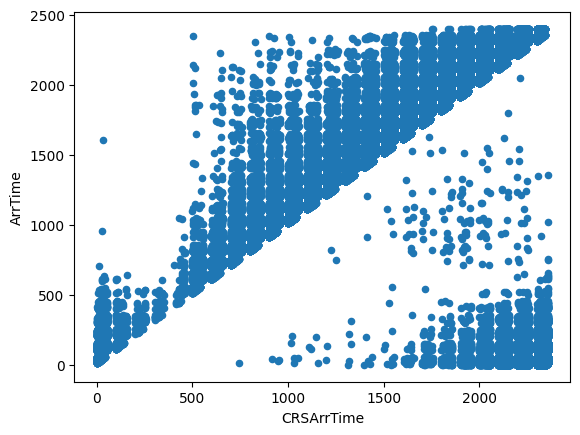

In [67]:
delay_causes.plot.scatter("CRSArrTime", "ArrTime")

<Axes: xlabel='CRSArrTime', ylabel='DepTime'>

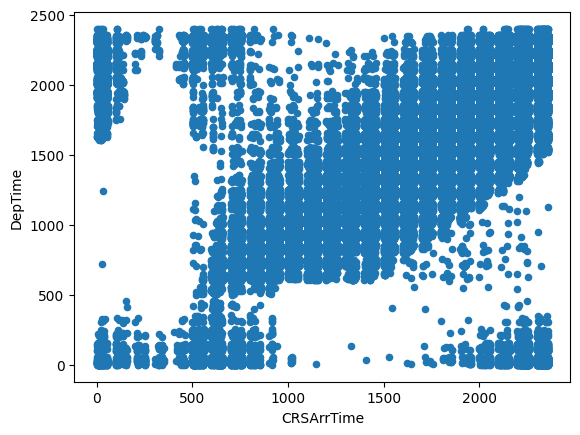

In [68]:
delay_causes.plot.scatter("CRSArrTime", "DepTime")

I was curious why actual departure times had a stronger correlation to expected arrival times than actual arrival time to expected arrival times. It is a case of 24 hours time being represented as integers that is causing the confusion. If the bottom right section of the graph was relocated onto the top of the graph, where it would be if the hours kept ticking up after 24, then there would be a much stronger correlation between expected and actual arrival times.

In [69]:
data_to_shift = delay_causes[delay_causes["ArrTime"] < (delay_causes["CRSArrTime"] - 100)].index
delay_causes.loc[data_to_shift,"ArrTime"] = delay_causes.loc[data_to_shift,"ArrTime"] + 2400

<Axes: xlabel='CRSArrTime', ylabel='ArrTime'>

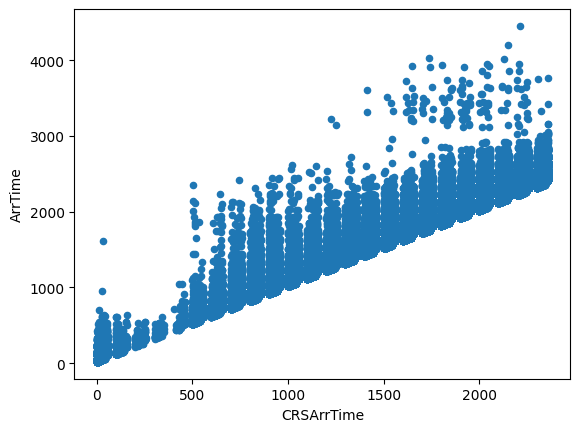

In [70]:
delay_causes.plot.scatter("CRSArrTime", "ArrTime")

In [71]:
delay_causes.drop(["FlightNum"], axis=1).corr(numeric_only=True)

,DayOfWeek,DepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
DayOfWeek,1.000000,0.018649,0.012158,0.013005,0.004801,0.009373,0.007838,-0.002553,0.003026,0.011913,0.011218,-0.016737,0.016825,0.001648,-0.026705,0.005742,-0.000288
DepTime,0.018649,1.000000,0.705417,0.702808,-0.072031,-0.055899,-0.066995,0.106641,0.132380,-0.064509,-0.042003,-0.026434,-0.042486,0.000472,0.004865,-0.018189,0.188047
ArrTime,0.012158,0.705417,1.000000,0.979535,0.028343,0.030819,0.019502,0.225803,0.231656,0.017987,0.012045,0.043443,0.007272,0.034105,0.070950,-0.016800,0.239623
CRSArrTime,0.013005,0.702808,0.979535,1.000000,0.010091,0.022882,0.011535,0.028813,0.045206,0.012402,-0.009453,-0.000573,-0.089387,-0.019192,-0.007640,-0.016704,0.143358
ActualElapsedTime,0.004801,-0.072031,0.028343,0.010091,1.000000,0.969723,0.975322,0.091506,0.009281,0.950683,0.175882,0.307644,0.029732,-0.004328,0.171725,0.000934,-0.031510
CRSElapsedTime,0.009373,-0.055899,0.030819,0.022882,0.969723,1.000000,0.986646,0.040953,0.036579,0.983551,0.110105,0.133169,0.045671,-0.025444,0.047489,0.001622,-0.011533
AirTime,0.007838,-0.066995,0.019502,0.011535,0.975322,0.986646,1.000000,0.039962,0.011101,0.977436,0.097938,0.103517,0.037612,-0.024446,0.069139,0.002494,-0.022409
ArrDelay,-0.002553,0.106641,0.225803,0.028813,0.091506,0.040953,0.039962,1.000000,0.948856,0.027743,0.106703,0.220981,0.478471,0.266126,0.395435,-0.002701,0.505515
DepDelay,0.003026,0.132380,0.231656,0.045206,0.009281,0.036579,0.011101,0.948856,1.000000,0.027307,0.016591,-0.011958,0.505906,0.244019,0.235892,-0.001912,0.541351
Distance,0.011913,-0.064509,0.017987,0.012402,0.950683,0.983551,0.977436,0.027743,0.027307,1.000000,0.089174,0.090828,0.046906,-0.029203,0.023655,0.001891,-0.011010


That is a much more reasonable correlation between actual arrival times and expected arrival times

In [4]:
#Import 4th Dataset

domestic_data_2024 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\T100_Domestic_Market_and_Segment_Data_8942359590531559889.csv")

domestic_data_2024.head()

,OBJECTID,year,origin,enplanements,passengers,departures,arrivals,freight,mail
0,1,2024,01A,17,17,5,5,0,0
1,2,2024,05A,1,1,1,1,0,0
2,3,2024,06A,50,55,67,66,139,0
3,4,2024,09A,41,43,15,15,0,0
4,5,2024,1B1,32,32,7,7,0,0


In [30]:
domestic_data_2024.drop(["OBJECTID","year"], axis=1).corr(numeric_only=True)

,enplanements,passengers,departures,arrivals,freight,mail
enplanements,1.000000,0.999996,0.986513,0.986801,0.260780,0.223404
passengers,0.999996,1.000000,0.986554,0.986843,0.261080,0.223639
departures,0.986513,0.986554,1.000000,0.999969,0.350464,0.288593
arrivals,0.986801,0.986843,0.999969,1.000000,0.345962,0.286451
freight,0.260780,0.261080,0.350464,0.345962,1.000000,0.646322
mail,0.223404,0.223639,0.288593,0.286451,0.646322,1.000000


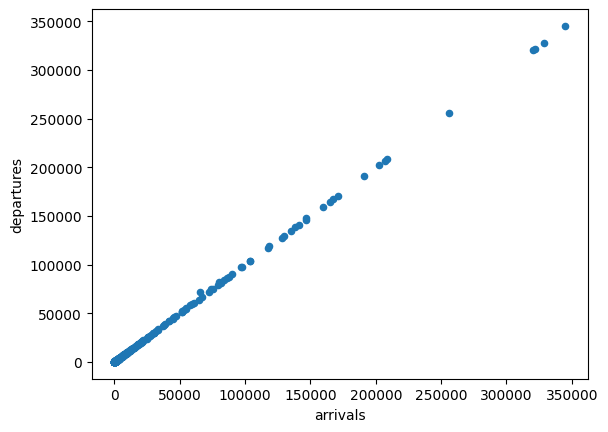

In [31]:
domestic_data_2024.plot.scatter("arrivals", "departures");

I am not surprised to find that the arrivals and departures at specific airports and nearly identical. If that were not the case, planes would be sitting at certain airports indefinitely. These two variables are redundant.

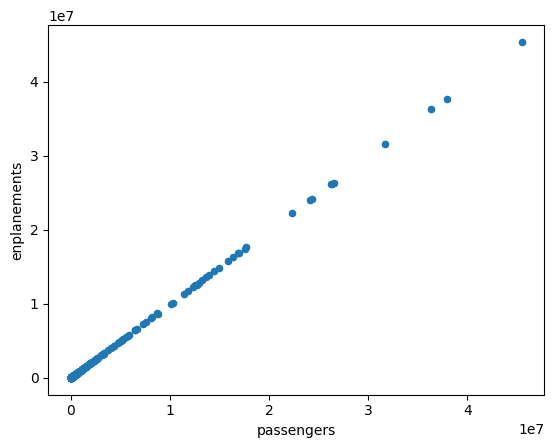

In [32]:
domestic_data_2024.plot.scatter("passengers", "enplanements");

Once again, these two variables being highly correlated makes sense and shows that they are redundant for analysis purposes. Enplanements is the count of individuals that actually boared the flights, whereas passengers can be a count of individuals who checked in for a flight.

In [33]:
domestic_data_2024[domestic_data_2024["enplanements"]>domestic_data_2024["passengers"]]

,OBJECTID,year,origin,enplanements,passengers,departures,arrivals,freight,mail
41,42,2024,A43,1011,964,939,924,207614,21728
46,47,2024,A65,4,2,5,6,0,0
100,101,2024,APF,591,587,91,94,0,0
405,406,2024,FXE,75,60,32,35,0,0
609,610,2024,KXA,2,1,50,53,2105,3749
941,942,2024,PTD,127,126,97,97,402,1150
1148,1149,2024,TMB,41,36,20,18,0,0
1195,1196,2024,UST,30,28,7,10,0,0
1238,1239,2024,WHD,56,54,69,69,1068,3091


I can not explain how certain airports reported higher number of enplanements than passengers. This could be incorrect data.

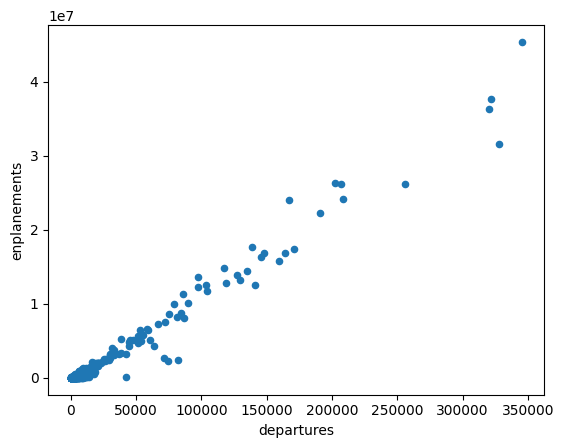

In [34]:
domestic_data_2024.plot.scatter("departures", "enplanements");

Unsurprisingly, the more planes that leave an airport, the more people fly out of that airport.

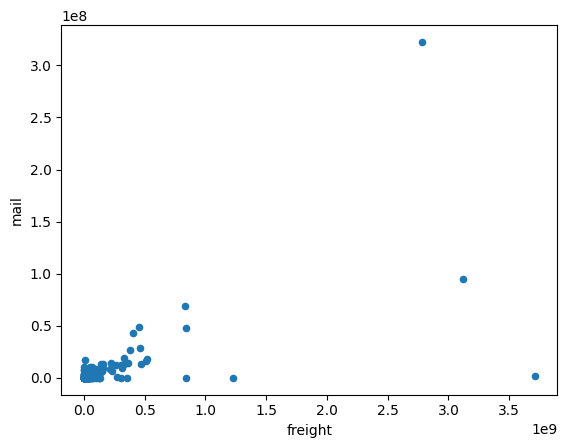

In [35]:
domestic_data_2024.plot.scatter("freight", "mail");

In [9]:
domestic_data_2024.iloc[domestic_data_2024["freight"].idxmax()] 

OBJECTID               708
year                  2024
origin                 MEM
enplanements       2437316
passengers         2468198
departures           82214
arrivals             80322
freight         3710072450
mail               2281969
Name: 707, dtype: object

In [10]:
domestic_data_2024.iloc[domestic_data_2024["mail"].idxmax()] 

OBJECTID              1032
year                  2024
origin                 SDF
enplanements       2342487
passengers         2381507
departures           74603
arrivals             73963
freight         2783912290
mail             322487696
Name: 1031, dtype: object

I had expected these two to have a higher correlation, but I supposed it makes sense that there are airports that specialize in one or the other more.

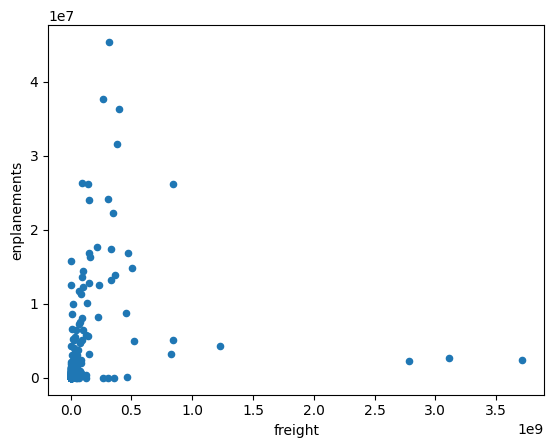

In [5]:
domestic_data_2024.plot.scatter("freight", "enplanements");

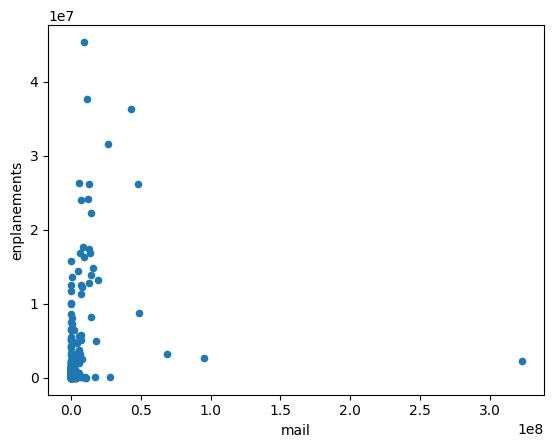

In [7]:
domestic_data_2024.plot.scatter("mail", "enplanements");

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

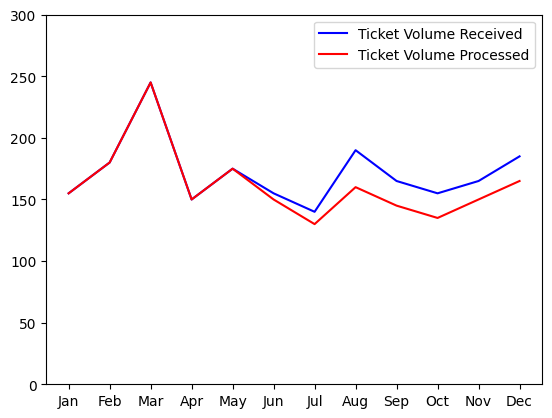

In [8]:
graph_data_1 = [155,180,245,150,175,150,130,160,145,135,150,165]
graph_data_2 = [155,180,245,150,175,155,140,190,165,155,165,185]
x_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(x_labels, graph_data_2, label = "Ticket Volume Received", color = "blue")
plt.plot(x_labels, graph_data_1, label = "Ticket Volume Processed", color = "red")

plt.ylim(0,300)
plt.legend();